In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROJECT_ROOT = Path.cwd().parent
SURFACES_DIR = PROJECT_ROOT / 'data' / 'surfaces'
FIG_DIR = PROJECT_ROOT / 'results' / 'tensor_pca' / 'figures'
TAB_DIR = PROJECT_ROOT / 'results' / 'tensor_pca' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

Z_state = pd.read_parquet(SURFACES_DIR / 'tensor_pca_state.parquet')
factors_data = np.load(SURFACES_DIR / 'tensor_pca_factors.npz', allow_pickle=True)
diagnostics = pd.read_csv(SURFACES_DIR / 'tensor_pca_diagnostics.csv')

U_time = factors_data['U_time']
V_moneyness = factors_data['V_moneyness']
W_maturity = factors_data['W_maturity']
S_venue = factors_data['S_venue']
weights = factors_data['weights']
k_grid = factors_data['k_grid']
tau_grid = factors_data['tau_grid']
t_grid_days = factors_data['t_grid_days']
venues = factors_data['venues']

R = U_time.shape[1]
print(f'Decomposition rank: R = {R}')
print(f'Trading days:       {U_time.shape[0]}')
print(f'Moneyness points:   {len(k_grid)}')
print(f'Maturity points:    {list(t_grid_days)}')
print(f'Venues:             {list(venues)}')

Decomposition rank: R = 1
Trading days:       772
Moneyness points:   27
Maturity points:    [np.int64(9), np.int64(27), np.int64(45)]
Venues:             [np.str_('CME'), np.str_('DER')]


#### 1. CORCONDIA Rank Selection (Thesis Table)

=== Rank Selection Diagnostics ===
 rank  reconstruction_error  explained      corcondia
    1              0.456992   0.791158     100.000000
    2              0.379516   0.855968     -56.242200
    3              0.277777   0.922840 -151410.750191
    4              0.235636   0.944475    -174.786970
    5              0.199047   0.960380    -117.837889
    6              0.177054   0.968652 -201421.685835


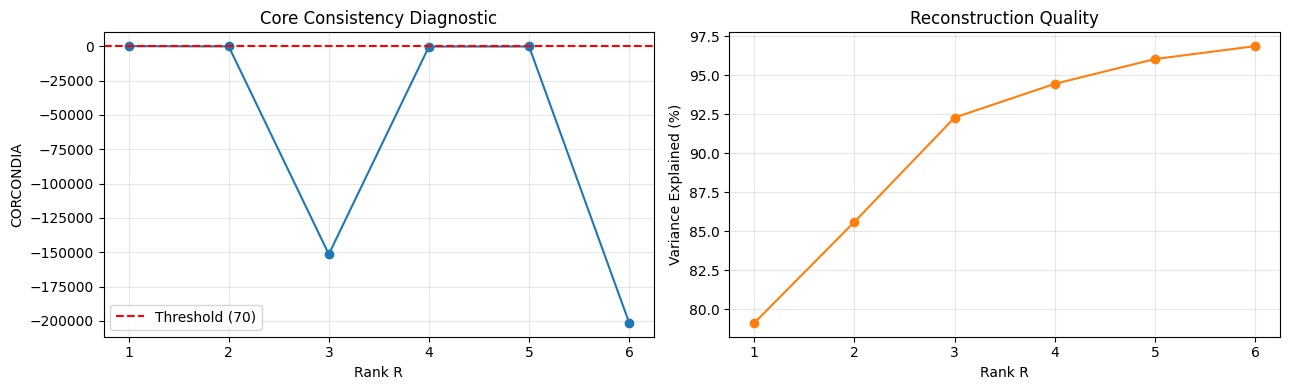

In [2]:
print('=== Rank Selection Diagnostics ===')
print(diagnostics.to_string(index=False))

diagnostics.to_csv(TAB_DIR / 'rank_selection.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(diagnostics['rank'], diagnostics['corcondia'], 'o-', color='C0')
axes[0].axhline(70, color='red', linestyle='--', label='Threshold (70)')
axes[0].set_xlabel('Rank R')
axes[0].set_ylabel('CORCONDIA')
axes[0].set_title('Core Consistency Diagnostic')
axes[0].legend()

axes[1].plot(diagnostics['rank'], diagnostics['explained'] * 100, 'o-', color='C1')
axes[1].set_xlabel('Rank R')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Reconstruction Quality')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_rank_selection.png', dpi=150)
plt.show()

#### 2. Moneyness Mode Factors (Level / Skew / Curvature)

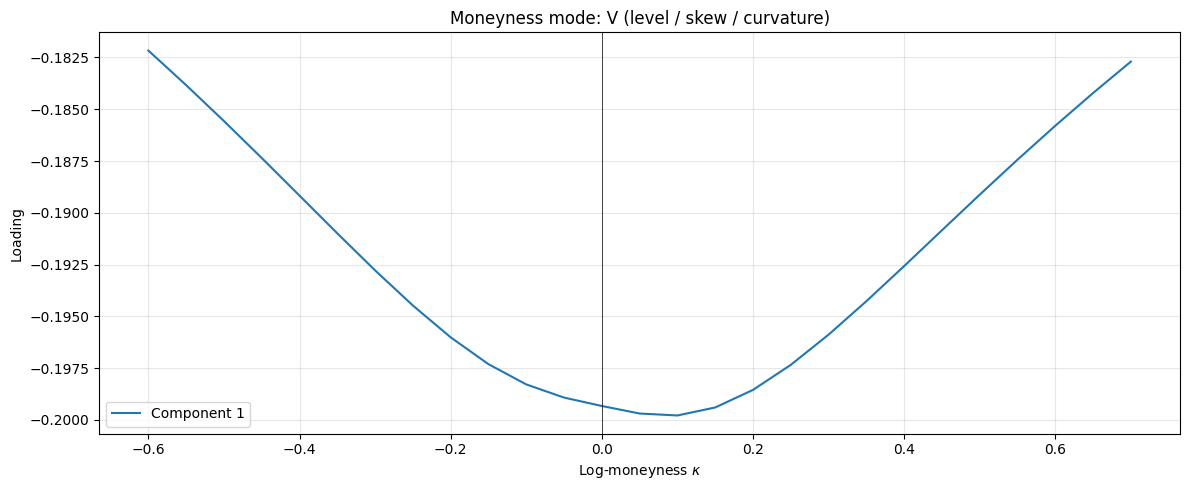

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
for r in range(R):
    ax.plot(k_grid, V_moneyness[:, r], label=f'Component {r+1}', linewidth=1.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel(r'Log-moneyness $\kappa$')
ax.set_ylabel('Loading')
ax.set_title('Moneyness mode: V (level / skew / curvature)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_factor_moneyness.png', dpi=150)
plt.show()

#### 3. Maturity Mode Factors (Term-Structure Shape)

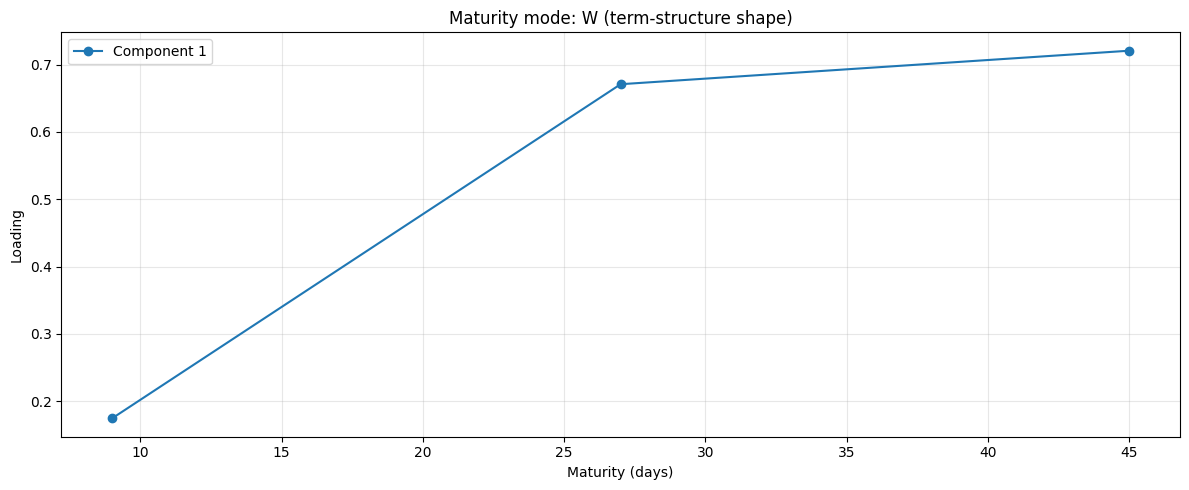

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
tau_days = t_grid_days
for r in range(R):
    ax.plot(tau_days, W_maturity[:, r], 'o-', label=f'Component {r+1}', linewidth=1.5)
ax.set_xlabel('Maturity (days)')
ax.set_ylabel('Loading')
ax.set_title('Maturity mode: W (term-structure shape)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_factor_maturity.png', dpi=150)
plt.show()

#### 4. Venue Mode Factors (CME vs. Deribit)

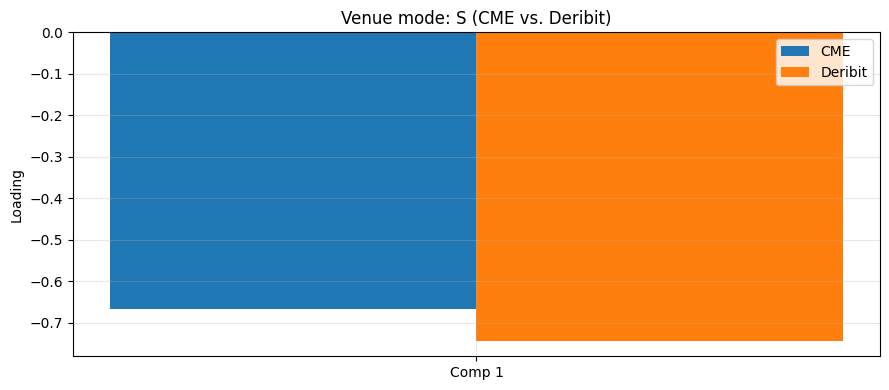

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(R)
width = 0.35
ax.bar(x - width/2, S_venue[0, :], width, label='CME', color='C0')
ax.bar(x + width/2, S_venue[1, :], width, label='Deribit', color='C1')
ax.set_xticks(x)
ax.set_xticklabels([f'Comp {r+1}' for r in range(R)])
ax.set_ylabel('Loading')
ax.set_title('Venue mode: S (CME vs. Deribit)')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_factor_venue.png', dpi=150)
plt.show()

#### 5. Temporal Scores Z^{IVS}_t (Thesis Figure)

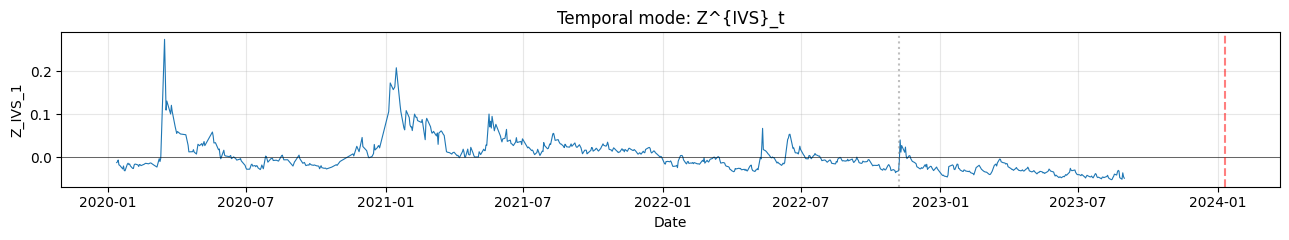

In [6]:
fig, axes = plt.subplots(R, 1, figsize=(13, 2.5 * R), sharex=True)
if R == 1:
    axes = [axes]
for r in range(R):
    axes[r].plot(Z_state.index, Z_state.iloc[:, r], linewidth=0.8, color=f'C{r}')
    axes[r].axhline(0, color='black', linewidth=0.4)
    axes[r].set_ylabel(f'Z_IVS_{r+1}')
    axes[r].axvline(pd.Timestamp('2022-11-08'), color='gray', linestyle=':', alpha=0.5)
    axes[r].axvline(pd.Timestamp('2024-01-10'), color='red', linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Date')
axes[0].set_title('Temporal mode: Z^{IVS}_t')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_factor_time.png', dpi=150)
plt.show()

#### 6. Component Summary Table (Common vs. Venue-Wedge)

In [7]:
summary = pd.DataFrame({
    'Component': [f'{r+1}' for r in range(R)],
    'Weight': weights.round(4),
    'CME loading': S_venue[0, :].round(4),
    'Deribit loading': S_venue[1, :].round(4),
    'Common': np.sign(S_venue[0, :]) == np.sign(S_venue[1, :]),
})
print('=== Component Summary ===')
print(summary.to_string(index=False))

summary.to_csv(TAB_DIR / 'component_summary.csv', index=False)

=== Component Summary ===
Component   Weight  CME loading  Deribit loading  Common
        1 265.6645      -0.6682           -0.744    True


#### 7. Validation Against Auxiliary Conditioning Variables

In [8]:
CLEAN = PROJECT_ROOT / 'data' / 'cleaned'
aux = pd.read_parquet(CLEAN / 'auxiliary_panel.parquet')
aux['date'] = pd.to_datetime(aux['date'])

merged = Z_state.reset_index().merge(aux, on='date', how='left')
corr_cols = [f'Z_IVS_{r+1}' for r in range(R)]
aux_cols = ['vix', 'rv', 'dvol']
corr = merged[corr_cols + aux_cols].corr().loc[corr_cols, aux_cols]

print('=== Correlation of Z^{IVS}_t with auxiliary variables ===')
print(corr.round(3))

corr.to_csv(TAB_DIR / 'state_aux_correlations.csv')

=== Correlation of Z^{IVS}_t with auxiliary variables ===
           vix     rv   dvol
Z_IVS_1  0.349  0.695  0.969


#### 8. Reconstruction Check (Sample Surface)

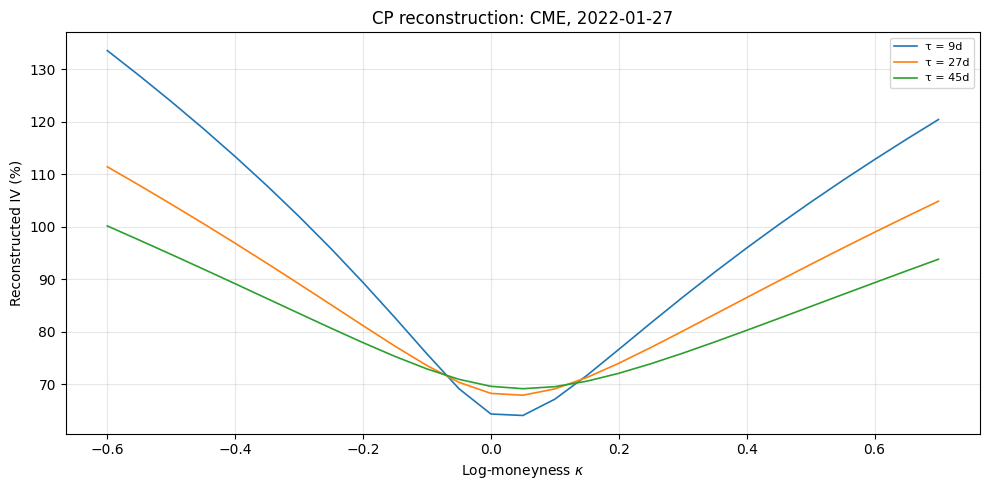


✅ Tensor PCA validation complete.
   State vector: c:\Projects\bitcoin-risk-premia\data\surfaces\tensor_pca_state.parquet
   Figures:      c:\Projects\bitcoin-risk-premia\results\tensor_pca\figures
   Tables:       c:\Projects\bitcoin-risk-premia\results\tensor_pca\tables


In [9]:
# Reconstruct surface for one sample (date, venue) and overlay vs. SSVI ground truth
mu_tensor = factors_data['mu_tensor']
sigma_tensor = factors_data['sigma_tensor']

sample_t = U_time.shape[0] // 2
sample_j = 0
sample_date = Z_state.index[sample_t]

X_hat_std = np.zeros((len(k_grid), len(tau_grid)))
for r in range(R):
    X_hat_std += (weights[r] * U_time[sample_t, r] * S_venue[sample_j, r] *
                  np.outer(V_moneyness[:, r], W_maturity[:, r]))
X_hat = X_hat_std * sigma_tensor[:, :, sample_j] + mu_tensor[:, :, sample_j]

fig, ax = plt.subplots(figsize=(10, 5))
for d_idx, tau in enumerate(tau_grid):
    iv_hat = np.sqrt(np.maximum(X_hat[:, d_idx], 1e-12) / tau) * 100
    ax.plot(k_grid, iv_hat, label=f'τ = {t_grid_days[d_idx]}d', linewidth=1.2)

ax.set_xlabel(r'Log-moneyness $\kappa$')
ax.set_ylabel('Reconstructed IV (%)')
ax.set_title(f'CP reconstruction: {venues[sample_j]}, {sample_date.date()}')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_reconstruction_sample.png', dpi=150)
plt.show()

print(f'\n✅ Tensor PCA validation complete.')
print(f'   State vector: {SURFACES_DIR / "tensor_pca_state.parquet"}')
print(f'   Figures:      {FIG_DIR}')
print(f'   Tables:       {TAB_DIR}')

#### 9. CP mode factors combined panel (moneyness + maturity + venue)

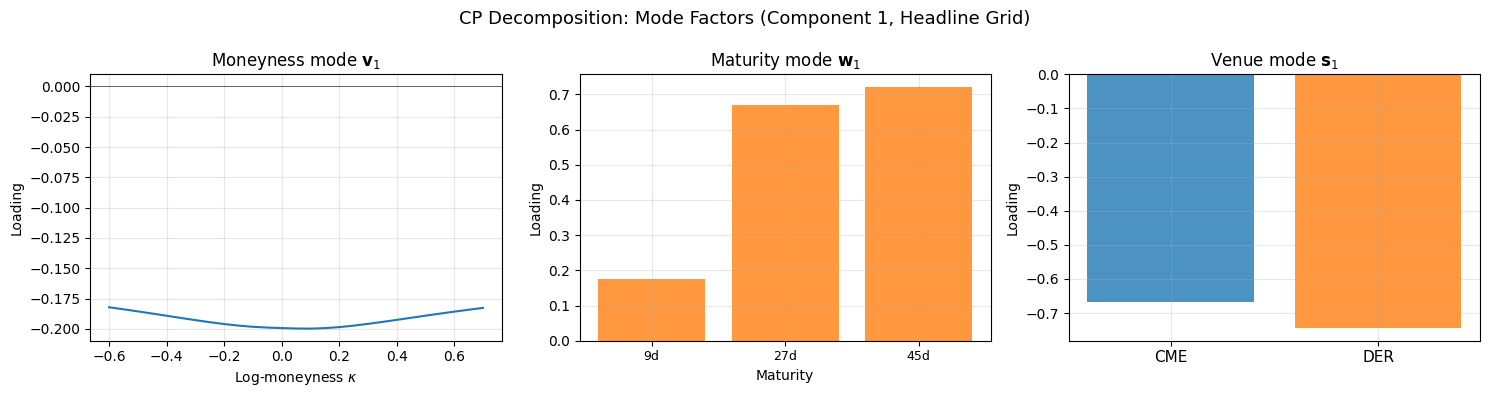

In [10]:
npz_path = SURFACES_DIR / "tensor_pca_factors_almeida.npz"

if not npz_path.exists():
    print("    [WARN] No tensor factors file found, skipping.")
else:
    data_comb = np.load(npz_path, allow_pickle=True)
    V_comb = data_comb["V_moneyness"][:, 0]  # moneyness mode, component 1
    W_comb = data_comb["W_maturity"][:, 0]   # maturity mode, component 1
    S_comb = data_comb["S_venue"][:, 0]      # venue mode, component 1
    k_grid_comb = data_comb["k_grid"]
    t_grid_days_comb = data_comb["t_grid_days"]
    venues_comb = data_comb["venues"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Panel 1: Moneyness mode
    ax = axes[0]
    ax.plot(k_grid_comb, V_comb, "C0-", lw=1.5)
    ax.axhline(0, color="black", lw=0.4)
    ax.set_xlabel(r"Log-moneyness $\kappa$")
    ax.set_ylabel("Loading")
    ax.set_title("Moneyness mode $\\mathbf{v}_1$")

    # Panel 2: Maturity mode
    ax = axes[1]
    ax.bar(range(len(t_grid_days_comb)), W_comb, color="C1", alpha=0.8)
    ax.set_xticks(range(len(t_grid_days_comb)))
    ax.set_xticklabels([f"{d}d" for d in t_grid_days_comb], fontsize=9)
    ax.axhline(0, color="black", lw=0.4)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Loading")
    ax.set_title("Maturity mode $\\mathbf{w}_1$")

    # Panel 3: Venue mode
    ax = axes[2]
    colors = ["C0", "C1"]
    ax.bar(range(len(venues_comb)), S_comb, color=colors, alpha=0.8)
    ax.set_xticks(range(len(venues_comb)))
    ax.set_xticklabels(venues_comb, fontsize=11)
    ax.axhline(0, color="black", lw=0.4)
    ax.set_ylabel("Loading")
    ax.set_title("Venue mode $\\mathbf{s}_1$")

    fig.suptitle("CP Decomposition: Mode Factors (Component 1, Headline Grid)", fontsize=13)
    plt.tight_layout()
    
    # Save to disk and display inline inside the notebook
    plt.savefig(FIG_DIR / "fig_cp_modes_combined.png", dpi=150)
    plt.show()